In [10]:
%pip install noise numpy matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from noise import pnoise3
import math
import hashlib

# Color mapping dictionary for visualization
ROAD_TYPES_MAP = {
    0: {
        'color': [0.0, 0.4, 0.0], # Dark green for terrain
        'radius': 0
    },
    1: {
        'color': [0.6, 0.6, 0.6], # Gray for highways
        'radius': 6
    },     
    2: {
        'color': [0.8, 0.8, 0.6], # Light beige for roads
        'radius': 4
    },     
    3: {
        'color': [0.4, 0.4, 0.4], # Dark gray for streets
        'radius': 2
    },     
}

def apply_color_map(array, color_map):
    """
    Apply color mapping to a 2D array of integers.
    
    Args:
        array: 2D numpy array with integer values
        color_map: Dictionary mapping integers to RGB colors (as lists/tuples)
    
    Returns:
        3D numpy array with shape (height, width, 3) for RGB visualization
    """
    height, width = array.shape
    # Initialize with dark green as default color (for terrain/background)
    colored = np.full((height, width, 3), [0.0, 0.4, 0.0])
    
    for value, properties in color_map.items():
        mask = array == value
        colored[mask] = properties['color']
    
    return colored

# Utility: draw filled disk into canvas
def draw_disk(canvas, x, y, radius=2):
    h, w = canvas.shape
    xi = int(round(x))
    yi = int(round(y))
    rx = range(max(0, xi-radius), min(w, xi+radius+1))
    ry = range(max(0, yi-radius), min(h, yi+radius+1))
    rr = radius*radius
    for nx in rx:
        for ny in ry:
            dx = nx - x
            dy = ny - y
            if dx*dx + dy*dy <= rr:
                canvas[ny, nx] = 1  # Changed from 255 to 1

# Quantized angle sampling using Perlin (noise.pnoise3)
def quantized_angle(x, y, scale, grid_angles, noise_strength, seed):
    # pnoise3 returns in [-1,1] for typical usage; keep it deterministic via seed offset
    val = pnoise3(x*scale, y*scale, seed) * noise_strength
    # clamp to [-1,1] then map to [0,1] range for more stable rounding
    val = max(-1.0, min(1.0, val))
    base = round(val * grid_angles) * (2.0 * math.pi / grid_angles)
    return base

## Chunk-aware generation

We implement a chunk-aware generator which: uses global/world coordinates for Perlin sampling, places deterministic worm starts via a spatial hash, and generates with padding so roads crossing borders appear in adjacent chunks.

In [12]:
def spatial_hash(seed, i, j, k=0):
    # deterministic float in [0,1) from integer inputs
    m = hashlib.sha256()
    m.update(f'{seed}:{i}:{j}:{k}'.encode('utf-8'))
    h = m.digest()
    # take first 8 bytes as uint64
    v = int.from_bytes(h[:8], 'little')
    return (v & ((1<<53)-1)) / float(1<<53)

# Utility: draw filled disk with specific value into canvas
def draw_disk(canvas, x, y, road_type):
    h, w = canvas.shape
    radius = ROAD_TYPES_MAP[road_type]['radius']
    value = road_type
    xi = int(round(x))
    yi = int(round(y))
    rx = range(max(0, xi-radius), min(w, xi+radius+1))
    ry = range(max(0, yi-radius), min(h, yi+radius+1))
    rr = radius*radius
    for nx in rx:
        for ny in ry:
            dx = nx - x
            dy = ny - y
            if dx*dx + dy*dy <= rr:
                canvas[ny, nx] = value

In [13]:
def generate_highways(canvas, gx, gy, world_offset_x, world_offset_y, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed):
    """
    Generate highways on the canvas.
    
    Args:
        canvas: The 2D array to draw on (values 0 for terrain)
        gx, gy: Grid cell coordinates for calculating start positions
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes
        step_size: Distance moved per step
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
    
    Returns:
        canvas: The modified canvas with highways marked as 1
    """
    return canvas

In [14]:
def generate_roads(canvas, gx, gy, world_offset_x, world_offset_y, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed):
    """
    Generate roads on the canvas.
    
    Args:
        canvas: The 2D array to draw on (values 0 for terrain, 1 for highways)
        gx, gy: Grid cell coordinates for calculating start positions
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes
        step_size: Distance moved per step
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
    
    Returns:
        canvas: The modified canvas with roads marked as 2
    """
    # Calculate cell spacing (same logic as in generate_chunk)
    chunk_size = canvas.shape[0]  # Assuming square canvas
    padding = (chunk_size - 256) // 2  # Reverse calculate padding
    cell_spacing = max(16, padding // 2)
    road_type = 2
    # Calculate start_x and start_y from gx, gy (same logic as in generate_chunk)
    u = spatial_hash(seed, gx, gy, 0)
    v = spatial_hash(seed, gx, gy, 1)
    start_x = gx * cell_spacing + u * cell_spacing
    start_y = gy * cell_spacing + v * cell_spacing
    
    # Draw the road worm using the new function with value 2
    x, y = start_x, start_y
    canvas_height, canvas_width = canvas.shape
    
    for j in range(worm_length):
        # Convert world coordinates to local canvas coordinates
        lx = x - world_offset_x
        ly = y - world_offset_y
        
        # Only draw if position is within canvas bounds
        if 0 <= lx < canvas_width and 0 <= ly < canvas_height:
            draw_disk(canvas, lx, ly, road_type=road_type)
        
        # Get direction from Perlin noise using world coordinates
        angle = quantized_angle(x, y, perlin_scale, grid_angles, noise_strength, seed)
        
        # Move to next position
        x += math.cos(angle) * step_size
        y += math.sin(angle) * step_size
    
    return canvas

In [20]:
def generate_streets(canvas, gx, gy, world_offset_x, world_offset_y, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed):
    """
    Generate streets on the canvas.
    
    Args:
        canvas: The 2D array to draw on (values 0 for terrain, 1 for highways, 2 for roads)
        gx, gy: Grid cell coordinates for calculating start positions
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes
        step_size: Distance moved per step
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
    
    Returns:
        canvas: The modified canvas with streets marked as 3
    """
    canvas_height, canvas_width = canvas.shape
    road_type = 3
    
    # Find all road pixels (value 2) to start streets from their edges
    road_pixels = np.where(canvas == 2)
    if len(road_pixels[0]) == 0:
        print("No roads to branch from")
        return canvas  # No roads to branch from
    
    # Increase the number of street starts - more aggressive street generation
    num_street_starts = min(len(road_pixels[0]) // 5, 200)  # Changed from //10 to //5, max increased to 50
    
    for i in range(num_street_starts):
        # Use spatial hash to deterministically select road pixels
        hash_val = spatial_hash(seed + 1000, gx, gy, i)
        road_idx = int(hash_val * len(road_pixels[0]))
        
        start_ly = road_pixels[0][road_idx]
        start_lx = road_pixels[1][road_idx]
        
        # Convert to world coordinates
        start_x = start_lx + world_offset_x
        start_y = start_ly + world_offset_y
        
        # Find the direction of the road at this point by checking neighboring road pixels
        road_direction = get_road_direction(canvas, start_lx, start_ly)
        
        # Generate perpendicular directions based on grid_angles
        perpendicular_angles = get_perpendicular_angles(road_direction, grid_angles)
        
        # Choose one of the perpendicular directions
        direction_hash = spatial_hash(seed + 2000, gx, gy, i)
        chosen_angle = perpendicular_angles[int(direction_hash * len(perpendicular_angles))]
        
        # Generate the street worm with longer length - convert to int
        street_length = int(worm_length * 2 // 3)  # Changed from //1.5 to *2//3 and convert to int
        generate_street_worm(canvas, start_x, start_y, world_offset_x, world_offset_y, 
                           street_length, step_size, chosen_angle, perlin_scale, 
                           grid_angles, noise_strength, seed + i, road_type)  # Increased noise from 0.5 to 0.7
    
    return canvas

def get_road_direction(canvas, x, y):
    """
    Estimate the direction of a road at a given point by checking neighboring pixels.
    
    Returns:
        Average angle of the road direction in radians
    """
    directions = []
    
    # Check 8 neighboring directions
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            
            nx, ny = x + dx, y + dy
            if 0 <= nx < canvas.shape[1] and 0 <= ny < canvas.shape[0]:
                if canvas[ny, nx] == 2:  # Road pixel
                    angle = math.atan2(dy, dx)
                    directions.append(angle)
    
    if not directions:
        return 0  # Default direction if no neighbors found
    
    # Average the angles (handling circular nature)
    avg_x = sum(math.cos(angle) for angle in directions) / len(directions)
    avg_y = sum(math.sin(angle) for angle in directions) / len(directions)
    return math.atan2(avg_y, avg_x)

def get_perpendicular_angles(road_angle, grid_angles):
    """
    Get perpendicular angles based on the road direction and grid_angles.
    
    Args:
        road_angle: The estimated direction of the road in radians
        grid_angles: Number of discrete angle directions
    
    Returns:
        List of perpendicular angles
    """
    # Calculate the step size for grid angles
    angle_step = 2 * math.pi / grid_angles
    
    # Find perpendicular directions (90 degrees from road direction)
    perp1 = road_angle + math.pi / 2
    perp2 = road_angle - math.pi / 2
    
    # Quantize to grid angles
    perp1_quantized = round(perp1 / angle_step) * angle_step
    perp2_quantized = round(perp2 / angle_step) * angle_step
    
    return [perp1_quantized, perp2_quantized]

def generate_street_worm(canvas, start_x, start_y, world_offset_x, world_offset_y, 
                        worm_length, step_size, initial_angle, perlin_scale, 
                        grid_angles, noise_strength, seed, road_type):
    """
    Generate a single street worm with constraints.
    
    Args:
        canvas: The 2D array to draw on
        start_x, start_y: Starting position in world coordinates
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes (must be integer)
        step_size: Distance moved per step
        initial_angle: Initial direction angle in radians
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
        road_type: The value to set for streets (3)
    """
    x, y = start_x, start_y
    canvas_height, canvas_width = canvas.shape
    current_angle = initial_angle
    
    # Reduced minimum distance before allowing turns for more organic streets
    min_straight_distance = 2  # Changed from 3 to 2
    steps_since_turn = 0
    
    for j in range(worm_length):
        # Convert world coordinates to local canvas coordinates
        lx = x - world_offset_x
        ly = y - world_offset_y

        # Calculate next position
        next_x = x + math.cos(current_angle) * step_size
        next_y = y + math.sin(current_angle) * step_size
        
        # Convert next position to local canvas coordinates
        next_lx = next_x - world_offset_x
        next_ly = next_y - world_offset_y
        
        # Check if next position will be out of bounds
        if not (0 <= next_lx < canvas_width and 0 <= next_ly < canvas_height):
            break
            
        # Check if next position will hit a road (stop the street before hitting)
        if canvas[int(next_ly), int(next_lx)] == 2:
            break
            
        # Only draw if position is within canvas bounds and not on a road
        if 0 <= lx < canvas_width and 0 <= ly < canvas_height:
            if canvas[int(ly), int(lx)] == 0:  # Only draw on terrain
                draw_disk(canvas, lx, ly, road_type=road_type)
        
        # Update angle with noise, but less frequently than roads
        if steps_since_turn >= min_straight_distance:
            # Allow turns with reduced noise influence
            noise_angle = quantized_angle(x, y, perlin_scale * 2, grid_angles, noise_strength, seed)
            
            # Reduced threshold for turning to allow more turns
            angle_diff = abs(noise_angle - current_angle)
            if angle_diff > math.pi / (grid_angles * 3):  # Changed from *2 to *3 for easier turning
                current_angle = noise_angle
                steps_since_turn = 0
        
        # Move to next position
        x = next_x
        y = next_y
        steps_since_turn += 1

In [16]:
def generate_chunk(chunk_x, chunk_y, chunk_size=256, padding=64, num_highways=2, num_roads=200, num_streets=100, worm_length=800, step_size=1.0, perlin_scale=0.01, seed=2, grid_angles=4, noise_strength=1.0, road_width=3):
    # world region to generate (with padding)
    wx = chunk_x * chunk_size - padding
    wy = chunk_y * chunk_size - padding
    size = chunk_size + 2*padding
    canvas = np.zeros((size, size), dtype=np.uint8)  # Canvas with 0s (terrain)
    
    # Choose a fixed global grid spacing (cells that hold deterministic start offsets)
    cell_spacing = max(16, padding // 2)
    gx_min = math.floor(wx / cell_spacing)
    gx_max = math.floor((wx + size) / cell_spacing)
    gy_min = math.floor(wy / cell_spacing)
    gy_max = math.floor((wy + size) / cell_spacing)
    
    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_highways:
                break
            
            # Stage 1: Generate highways (value 1)
            canvas = generate_highways(canvas, gx, gy, wx, wy, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed)
            count += 1
    
    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_roads:
                break

            # Stage 2: Generate roads (value 2)
            canvas = generate_roads(canvas, gx, gy, wx, wy, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed)
            count += 1

    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_streets:
                break

            # Stage 3: Generate streets (value 3)
            canvas = generate_streets(canvas, gx, gy, wx, wy, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed)
            count += 1
    
    # crop to chunk region
    sx = padding
    sy = padding
    cropped = canvas[sy:sy+chunk_size, sx:sx+chunk_size].copy()
    return cropped

Stitched array shape: (768, 768)
Unique values in array: [0 2 3]
Number of terrain pixels (0s): 484216
Number of highway pixels (1s): 0
Number of road pixels (2s): 78491
Number of street pixels (3s): 27117


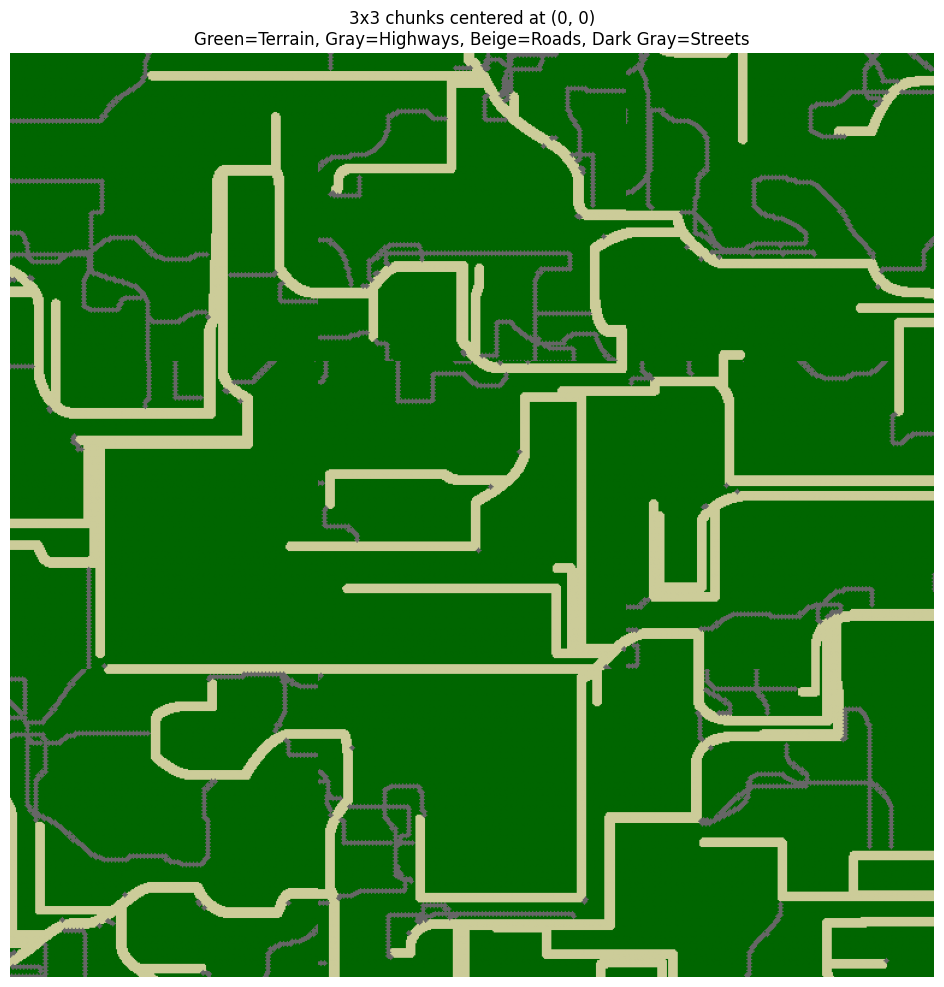

In [21]:
# Generate a square grid of chunks centered on a given chunk coordinate
# Specify the center chunk coordinates (world chunk indices) and a radius (half-size).
# radius=2 -> 5x5 grid
center_x, center_y = 0, 0  # change these to any world chunk coordinates
radius = 1
rows = []
for gy in range(center_y - radius, center_y + radius + 1):
    row_chunks = []
    for gx in range(center_x - radius, center_x + radius + 1):
        # generate each chunk at global chunk coordinates (gx, gy)
        # The new refactored generate_chunk handles highways, roads, and streets internally
        c = generate_chunk(
            gx, gy,
            chunk_size=256,
            padding=256,
            num_highways=2,
            num_roads=200,
            num_streets=300,  # Increased from 100 to 300 for more streets
            worm_length=1000,
            seed=42,
            grid_angles=4,
            perlin_scale=0.01,
            road_width=5
        )
        
        row_chunks.append(c)
    # concatenate chunks horizontally for this row
    rows.append(np.hstack(row_chunks))
# stack all rows vertically to form the full grid
stitched = np.vstack(rows)

# Print some info about the generated data
print(f"Stitched array shape: {stitched.shape}")
print(f"Unique values in array: {np.unique(stitched)}")
print(f"Number of terrain pixels (0s): {np.sum(stitched == 0)}")
print(f"Number of highway pixels (1s): {np.sum(stitched == 1)}")
print(f"Number of road pixels (2s): {np.sum(stitched == 2)}")
print(f"Number of street pixels (3s): {np.sum(stitched == 3)}")

# Apply color mapping for visualization
colored_image = apply_color_map(stitched, ROAD_TYPES_MAP)

plt.figure(figsize=(12,12))
plt.imshow(colored_image, origin='lower')
plt.title(f'{(2*radius+1)}x{(2*radius+1)} chunks centered at ({center_x}, {center_y})\nGreen=Terrain, Gray=Highways, Beige=Roads, Dark Gray=Streets')
plt.axis('off')
plt.show()

Notes:
- This implementation uses global-coordinate Perlin sampling and deterministic worm starts via `spatial_hash`.
- Padding allows worms that start outside a chunk to paint into it, avoiding visible seams.
- Parameters (padding, num_worms, worm_length) trade memory and quality; tune per your needs.